# Wafer Anomaly Detection - Trained EfficientNet-B1 + PatchCore (WM-811K)

This notebook adds an explicit training stage before PatchCore:

1. Self-supervised rotation training on normal wafers
2. PatchCore memory bank build using fine-tuned EfficientNet features
3. Threshold tuning on tune-normal only (no defect leakage)
4. Final test evaluation and artifact export

In [17]:
# 0) Install optional deps if missing
import importlib, subprocess, sys
for pkg in ['tqdm']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('Dependencies ready')

Dependencies ready


In [18]:
# 1) Imports
import os, gc, json, random, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision.models import efficientnet_b1, EfficientNet_B1_Weights
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_CUDA = DEVICE.type == 'cuda'
if USE_CUDA:
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('high')

print('Device:', DEVICE)
if USE_CUDA:
    p = torch.cuda.get_device_properties(0)
    print(f'GPU: {p.name}  VRAM: {p.total_memory/1e9:.1f} GB')

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU  VRAM: 8.6 GB


In [ ]:
# 2) Config
DATA_PATH = '../../data/raw/LSWMD.pkl'
IMAGE_SIZE = 240

# Data splits
TRAIN_NORMAL_N = 40_000
TUNE_NORMAL_N  = 5_000
TEST_NORMAL_N  = 5_000
TEST_DEFECT_N  = 250

# Rotation self-supervised training
FINETUNE_EPOCHS = 10
FINETUNE_LR = 3e-5
FINETUNE_BATCH = 64
FINETUNE_WORKERS = 0
UNFREEZE_LAST_BLOCKS = 5

# PatchCore settings
EFFNET_DEEP_FEATURE_IDX = 5
PATCH_EMBED_DIM = 128
MEMORY_BANK_MAX = 200_000
BANK_BATCH_SIZE = 128
BANK_WORKERS = 0
SCORE_CHUNK = 1024
PATCHCORE_NN_K = 3
TOPK_PATCH_RATIO = 0.05

# Threshold settings
TARGET_FPR = 0.02

# Output paths
ARTIFACT_DIR = '../artifacts/trained_patchcore_efficientnet_b1'
FINETUNE_CKPT = os.path.join(ARTIFACT_DIR, 'effnet_b1_finetuned_backbone.pt')
MODEL_EXPORT_PATH = os.path.join(ARTIFACT_DIR, 'patchcore_effnet_b1_trained_model.pt')
METRICS_EXPORT_PATH = os.path.join(ARTIFACT_DIR, 'evaluation_metrics.json')
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print(f'Fine-tune: epochs={FINETUNE_EPOCHS}, lr={FINETUNE_LR}, batch={FINETUNE_BATCH}')
print(f'PatchCore: deep_idx={EFFNET_DEEP_FEATURE_IDX}, dim={PATCH_EMBED_DIM}, bank_cap={MEMORY_BANK_MAX:,}')
print('Artifacts ->', ARTIFACT_DIR)

Fine-tune: epochs=10, lr=3e-05, batch=64
PatchCore: deep_idx=3, dim=128, bank_cap=200,000
Artifacts -> ../artifacts/trained_patchcore_efficientnet_b1


In [20]:
# 3) Load + clean dataset
df = pd.read_pickle(DATA_PATH)
print('Raw shape:', df.shape)

def parse_failure_label(v):
    if v is None:
        return 'unknown'
    if isinstance(v, float) and np.isnan(v):
        return 'unknown'
    if isinstance(v, (list, tuple, np.ndarray)):
        arr = np.array(v).reshape(-1)
        return 'unknown' if len(arr) == 0 else str(arr[0])
    return str(v)

df = df.copy()
df['failure_label'] = df['failureType'].apply(parse_failure_label).str.strip()
invalid = {'0', 'unknown', 'nan', 'None', '[]'}
df = df[~df['failure_label'].isin(invalid)].copy()
df['is_anomaly'] = (df['failure_label'].str.lower() != 'none').astype(int)

normal_df = df[df['is_anomaly'] == 0].copy()
defect_df = df[df['is_anomaly'] == 1].copy()

print(f'Labeled: {len(df):,}  Normal: {len(normal_df):,}  Defect: {len(defect_df):,}')

Raw shape: (811457, 6)
Labeled: 172,950  Normal: 147,431  Defect: 25,519


In [21]:
# 4) Split
req_n = TRAIN_NORMAL_N + TUNE_NORMAL_N + TEST_NORMAL_N
if len(normal_df) < req_n:
    raise ValueError(f'Need {req_n:,} normals, have {len(normal_df):,}')
if len(defect_df) < TEST_DEFECT_N:
    raise ValueError(f'Need {TEST_DEFECT_N:,} defects, have {len(defect_df):,}')

rng = np.random.default_rng(SEED)
ns = normal_df.iloc[rng.permutation(len(normal_df))].reset_index(drop=True)
ds = defect_df.iloc[rng.permutation(len(defect_df))].reset_index(drop=True)

a = TRAIN_NORMAL_N
b = a + TUNE_NORMAL_N
c = b + TEST_NORMAL_N

train_normal_df = ns.iloc[:a].copy()
tune_normal_df = ns.iloc[a:b].copy()
test_normal_df = ns.iloc[b:c].copy()
test_defect_df = ds.iloc[:TEST_DEFECT_N].copy()

print('Train normal:', len(train_normal_df))
print('Tune normal :', len(tune_normal_df))
print('Test normal :', len(test_normal_df))
print('Test defect :', len(test_defect_df))

Train normal: 40000
Tune normal : 5000
Test normal : 5000
Test defect : 250


In [22]:
# 5) Lazy datasets
class BaseWaferDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, size: int = 240):
        self.maps = frame['waferMap'].values
        self.labels = frame['is_anomaly'].values.astype(np.int64)
        self.size = size

    def _to_tensor(self, idx):
        arr = np.clip(np.array(self.maps[idx], dtype=np.int64), 0, 2)
        x = torch.tensor(arr, dtype=torch.long)
        x = F.one_hot(x, num_classes=3).permute(2, 0, 1).float()
        x = F.interpolate(x.unsqueeze(0), size=(self.size, self.size), mode='nearest').squeeze(0)
        return x

    def __len__(self):
        return len(self.maps)

    def __getitem__(self, idx):
        return self._to_tensor(idx), int(self.labels[idx])


class RotationDataset(Dataset):
    def __init__(self, base_dataset: BaseWaferDataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, _ = self.base[idx]
        k = random.randint(0, 3)
        x_rot = torch.rot90(x, k=k, dims=[1, 2])
        return x_rot, k

base_ds = BaseWaferDataset(train_normal_df, IMAGE_SIZE)
rot_ds = RotationDataset(base_ds)
sx, sy = rot_ds[0]
print('Sample:', tuple(sx.shape), 'rot_class=', sy)

Sample: (3, 240, 240) rot_class= 0


## Stage 1 - Self-Supervised Rotation Training

EfficientNet-B1 is trained to predict rotation class (0, 90, 180, 270 degrees) on normal wafers only.
This gives domain-adapted features before PatchCore memory-bank construction.

In [23]:
# 6) Build rotation model from EfficientNet-B1
class RotationEffNet(nn.Module):
    def __init__(self, num_classes=4, unfreeze_last_blocks=2):
        super().__init__()
        backbone = efficientnet_b1(weights=EfficientNet_B1_Weights.DEFAULT)
        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Linear(1280, num_classes)

        for p in self.features.parameters():
            p.requires_grad = False

        n_blocks = len(self.features)
        for i in range(max(0, n_blocks - unfreeze_last_blocks), n_blocks):
            for p in self.features[i].parameters():
                p.requires_grad = True

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.head(x)

rot_model = RotationEffNet(num_classes=4, unfreeze_last_blocks=UNFREEZE_LAST_BLOCKS).to(DEVICE)
trainable = sum(p.numel() for p in rot_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in rot_model.parameters())
print(f'Trainable params: {trainable/1e6:.2f}M / {total/1e6:.2f}M')

Trainable params: 6.41M / 6.52M


In [24]:
# 7) Fine-tune loop
rot_loader = DataLoader(
    RotationDataset(BaseWaferDataset(train_normal_df, IMAGE_SIZE)),
    batch_size=FINETUNE_BATCH,
    shuffle=True,
    num_workers=FINETUNE_WORKERS,
    pin_memory=USE_CUDA,
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, rot_model.parameters()), lr=FINETUNE_LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINETUNE_EPOCHS * len(rot_loader))
scaler = torch.amp.GradScaler(enabled=USE_CUDA)

history = {'loss': [], 'acc': []}

for epoch in range(1, FINETUNE_EPOCHS + 1):
    rot_model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    pbar = tqdm(rot_loader, desc=f'Epoch {epoch}/{FINETUNE_EPOCHS}', leave=False)
    for xb, yb in pbar:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_CUDA):
            logits = rot_model(xb)
            loss = criterion(logits, yb)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total_samples += len(yb)
        total_loss += loss.item() * len(yb)

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc)
    print(f'Epoch {epoch:02d}: loss={epoch_loss:.4f} acc={epoch_acc:.4f}')

torch.save(rot_model.features.state_dict(), FINETUNE_CKPT)
print('Saved fine-tuned EfficientNet features to', FINETUNE_CKPT)

Epoch 01: loss=0.8440 acc=0.6778


Epoch 02: loss=0.2199 acc=0.9292


Epoch 03: loss=0.1267 acc=0.9591


Epoch 04: loss=0.0883 acc=0.9706


Epoch 05: loss=0.0714 acc=0.9777


Epoch 06: loss=0.0628 acc=0.9798


Epoch 07: loss=0.0533 acc=0.9819


Epoch 08: loss=0.0491 acc=0.9841


Epoch 09: loss=0.0481 acc=0.9844


Epoch 10: loss=0.0492 acc=0.9842
Saved fine-tuned EfficientNet features to ../artifacts/trained_patchcore_efficientnet_b1\effnet_b1_finetuned_backbone.pt


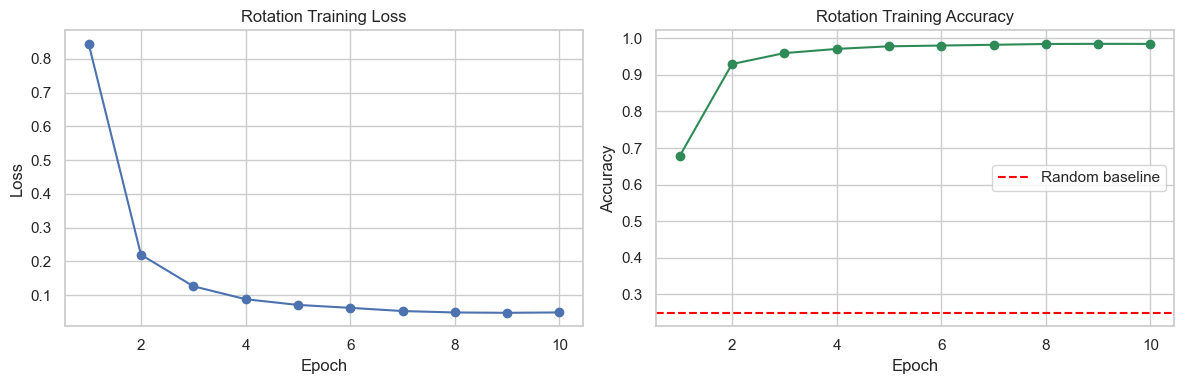

In [25]:
# 8) Plot fine-tune history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(history['loss']) + 1), history['loss'], marker='o')
axes[0].set_title('Rotation Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(range(1, len(history['acc']) + 1), history['acc'], marker='o', color='seagreen')
axes[1].axhline(0.25, color='red', linestyle='--', label='Random baseline')
axes[1].set_title('Rotation Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## Stage 2 - PatchCore with Fine-Tuned EfficientNet Features

In [26]:
# 9) PatchCore extractor with fine-tuned features
class FineTunedEffNetPatchExtractor(nn.Module):
    def __init__(self, feature_idx=3, proj_dim=128):
        super().__init__()
        base = efficientnet_b1(weights=None)
        self.features = base.features
        self.features.load_state_dict(torch.load(FINETUNE_CKPT, map_location='cpu'))
        self.feature_idx = feature_idx

        with torch.inference_mode():
            dummy = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)
            x = dummy
            feat = None
            for i, block in enumerate(self.features):
                x = block(x)
                if i == self.feature_idx:
                    feat = x
            if feat is None:
                raise ValueError('Invalid feature index')
            in_dim = feat.shape[1]

        self.proj = nn.Linear(in_dim, proj_dim, bias=False)

    def forward(self, x):
        feat = None
        for i, block in enumerate(self.features):
            x = block(x)
            if i == self.feature_idx:
                feat = x
        b, c, h, w = feat.shape
        patches = feat.permute(0, 2, 3, 1).reshape(b, h * w, c)
        return patches

extractor = FineTunedEffNetPatchExtractor(feature_idx=EFFNET_DEEP_FEATURE_IDX, proj_dim=PATCH_EMBED_DIM).to(DEVICE).eval()
for p in extractor.parameters():
    p.requires_grad = False

del rot_model
gc.collect()
if USE_CUDA:
    torch.cuda.empty_cache()

@torch.inference_mode()
def extract_embeddings(xb):
    with torch.amp.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_CUDA):
        feat = extractor(xb)
        emb = extractor.proj(feat)
    emb = emb.float().reshape(-1, emb.shape[-1])
    emb = F.normalize(emb, p=2, dim=1)
    return emb

In [27]:
# 10) Build memory bank
loader_kw = dict(batch_size=BANK_BATCH_SIZE, shuffle=False, num_workers=BANK_WORKERS, pin_memory=USE_CUDA, persistent_workers=(BANK_WORKERS > 0))
train_loader = DataLoader(BaseWaferDataset(train_normal_df, IMAGE_SIZE), **loader_kw)
tune_normal_loader = DataLoader(BaseWaferDataset(tune_normal_df, IMAGE_SIZE), **loader_kw)
test_normal_loader = DataLoader(BaseWaferDataset(test_normal_df, IMAGE_SIZE), **loader_kw)
test_defect_loader = DataLoader(BaseWaferDataset(test_defect_df, IMAGE_SIZE), **loader_kw)

sampled = []
sample_ratio = None

for step, (xb, _) in tqdm(enumerate(train_loader), total=len(train_loader), desc='Bank build'):
    xb = xb.to(DEVICE)
    emb = extract_embeddings(xb)

    if sample_ratio is None:
        patches_per_img = len(emb) // len(xb)
        est_total = patches_per_img * len(train_normal_df)
        sample_ratio = min(1.0, MEMORY_BANK_MAX / est_total)
        print('Patches/image:', patches_per_img, '| est_total:', est_total, '| sample_ratio:', round(sample_ratio, 6))

    if sample_ratio < 1.0:
        keep = max(1, int(round(len(emb) * sample_ratio)))
        idx = torch.randperm(len(emb), device=DEVICE)[:keep]
        emb = emb[idx]

    sampled.append(emb)

memory_bank = torch.cat(sampled, dim=0)
if len(memory_bank) > MEMORY_BANK_MAX:
    idx = torch.randperm(len(memory_bank), device=DEVICE)[:MEMORY_BANK_MAX]
    memory_bank = memory_bank[idx]

memory_bank = F.normalize(memory_bank, p=2, dim=1).contiguous()
print('Final bank:', len(memory_bank), 'x', memory_bank.shape[1])

Bank build:   1%|          | 2/313 [00:00<00:29, 10.39it/s]

Patches/image: 900 | est_total: 36000000 | sample_ratio: 0.005556


Bank build: 100%|██████████| 313/313 [00:33<00:00,  9.36it/s]

Final bank: 200000 x 128


In [28]:
# 11) Score helpers
@torch.inference_mode()
def score_loader(loader):
    scores, labels = [], []
    for xb, yb in tqdm(loader, desc='Scoring', leave=False):
        xb = xb.to(DEVICE)
        emb = extract_embeddings(xb)

        B = len(xb)
        P = emb.shape[0] // B

        patch_dists = torch.empty(B * P, dtype=torch.float32, device=DEVICE)
        for start in range(0, B * P, SCORE_CHUNK):
            end = min(start + SCORE_CHUNK, B * P)
            chunk = emb[start:end]
            d = torch.cdist(chunk, memory_bank)
            knn = d.topk(PATCHCORE_NN_K, dim=1, largest=False).values
            patch_dists[start:end] = knn.mean(dim=1)

        patch_dists = patch_dists.view(B, P)
        topk = max(1, int(P * TOPK_PATCH_RATIO))
        img_scores = patch_dists.topk(topk, dim=1).values.mean(dim=1)

        scores.extend(img_scores.cpu().tolist())
        labels.extend(yb.tolist())

    return np.array(scores), np.array(labels)

tune_scores, _ = score_loader(tune_normal_loader)
print('Tune normal mean/std:', tune_scores.mean(), tune_scores.std())

Tune normal mean/std: 0.541807414740324 0.04489715759677435


In [29]:
# 12) Threshold tuning from tune-normal only
mu = tune_scores.mean()
sd = tune_scores.std()
sigma_values = np.linspace(1.5, 3.5, 200)
candidate_thresholds = mu + sigma_values * sd
fprs = np.array([(tune_scores > t).mean() for t in candidate_thresholds])

best_idx = np.argmin(np.abs(fprs - TARGET_FPR))
best_sigma = sigma_values[best_idx]
best_thresh = candidate_thresholds[best_idx]
best_fpr = fprs[best_idx]

print(f'Threshold = mean + {best_sigma:.2f}*std = {best_thresh:.6f}')
print(f'Tune-normal FPR = {best_fpr:.4f} (target={TARGET_FPR})')

Threshold = mean + 2.14*std = 0.638032
Tune-normal FPR = 0.0200 (target=0.02)


In [30]:
# 13) Final evaluation + per-class breakdown
test_normal_scores, test_normal_labels = score_loader(test_normal_loader)
test_defect_scores, test_defect_labels = score_loader(test_defect_loader)

all_scores = np.concatenate([test_normal_scores, test_defect_scores])
all_labels = np.concatenate([test_normal_labels, test_defect_labels])
preds = (all_scores > best_thresh).astype(int)

roc_auc = roc_auc_score(all_labels, all_scores)
fpr_arr, tpr_arr, _ = roc_curve(all_labels, all_scores)

print('ROC-AUC:', round(float(roc_auc), 4))
print(classification_report(all_labels, preds, target_names=['Normal', 'Defect'], digits=4))

defect_labels = test_defect_df['failure_label'].values
defect_preds = (test_defect_scores > best_thresh).astype(int)
perclass_results = {}
for cls in sorted(np.unique(defect_labels)):
    m = defect_labels == cls
    n = int(m.sum())
    d = int(defect_preds[m].sum())
    r = float(d / n)
    ms = float(test_defect_scores[m].mean())
    perclass_results[cls] = {'n': n, 'detected': d, 'recall': r, 'mean_score': ms}
    print(f'{cls:<14} n={n:>4} detected={d:>4} recall={r:>6.1%} mean_score={ms:.4f}')

overall_defect_recall = float(defect_preds.sum() / len(defect_preds))
print('Overall defect recall:', f'{overall_defect_recall:.1%}')

ROC-AUC: 0.8861
              precision    recall  f1-score   support

      Normal     0.9707    0.9802    0.9754      5000
      Defect     0.5075    0.4080    0.4523       250

    accuracy                         0.9530      5250
   macro avg     0.7391    0.6941    0.7139      5250
weighted avg     0.9486    0.9530    0.9505      5250

Center         n=  34 detected=   4 recall= 11.8% mean_score=0.5955
Donut          n=   2 detected=   2 recall=100.0% mean_score=0.6642
Edge-Loc       n=  44 detected=  10 recall= 22.7% mean_score=0.6151
Edge-Ring      n= 102 detected=  65 recall= 63.7% mean_score=0.6582
Loc            n=  41 detected=   5 recall= 12.2% mean_score=0.5811
Near-full      n=   3 detected=   3 recall=100.0% mean_score=0.7128
Random         n=  13 detected=  12 recall= 92.3% mean_score=0.6937
Scratch        n=  11 detected=   1 recall=  9.1% mean_score=0.5691
Overall defect recall: 40.8%


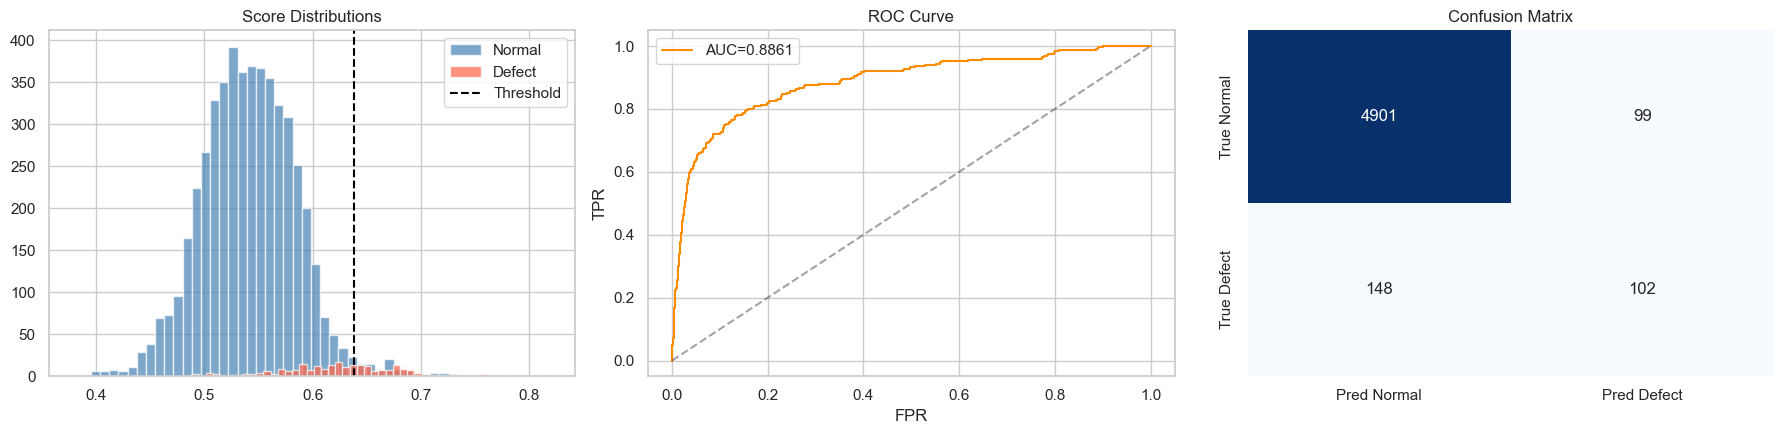

In [31]:
# 14) Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].hist(test_normal_scores, bins=50, alpha=0.7, label='Normal', color='steelblue')
axes[0].hist(test_defect_scores, bins=50, alpha=0.7, label='Defect', color='tomato')
axes[0].axvline(best_thresh, color='black', linestyle='--', label='Threshold')
axes[0].set_title('Score Distributions')
axes[0].legend()

axes[1].plot(fpr_arr, tpr_arr, color='darkorange', label=f'AUC={roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()

cm = confusion_matrix(all_labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2], cbar=False,
            xticklabels=['Pred Normal', 'Pred Defect'],
            yticklabels=['True Normal', 'True Defect'])
axes[2].set_title('Confusion Matrix')

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, 'evaluation_results.png'), dpi=130, bbox_inches='tight')
plt.show()

In [32]:
# 15) Save model + metrics
torch.save({
    'extractor_state': extractor.state_dict(),
    'memory_bank': memory_bank.detach().cpu(),
    'threshold': float(best_thresh),
    'threshold_sigma': float(best_sigma),
    'tune_mean': float(mu),
    'tune_std': float(sd),
    'feature_idx': int(EFFNET_DEEP_FEATURE_IDX),
    'proj_dim': int(PATCH_EMBED_DIM),
}, MODEL_EXPORT_PATH)

metrics = {
    'roc_auc': float(roc_auc),
    'threshold': float(best_thresh),
    'threshold_sigma': float(best_sigma),
    'tune_mean': float(mu),
    'tune_std': float(sd),
    'tune_fpr': float(best_fpr),
    'overall_defect_recall': float(overall_defect_recall),
    'bank_size': int(len(memory_bank)),
    'per_class': perclass_results,
    'finetune': {
        'epochs': int(FINETUNE_EPOCHS),
        'lr': float(FINETUNE_LR),
        'batch': int(FINETUNE_BATCH),
        'unfreeze_last_blocks': int(UNFREEZE_LAST_BLOCKS),
        'final_loss': float(history['loss'][-1]),
        'final_acc': float(history['acc'][-1]),
    }
}
with open(METRICS_EXPORT_PATH, 'w') as f:
    json.dump(metrics, f, indent=2)

print('Model saved  ->', MODEL_EXPORT_PATH)
print('Metrics saved ->', METRICS_EXPORT_PATH)

Model saved  -> ../artifacts/trained_patchcore_efficientnet_b1\patchcore_effnet_b1_trained_model.pt
Metrics saved -> ../artifacts/trained_patchcore_efficientnet_b1\evaluation_metrics.json


## Notes

- If CUDA OOM during fine-tune: reduce FINETUNE_BATCH (64 -> 32) or UNFREEZE_LAST_BLOCKS (2 -> 1).
- If CUDA OOM during scoring: reduce SCORE_CHUNK.
- If memory bank is too large: reduce MEMORY_BANK_MAX.
- Threshold is tuned from tune-normal only to avoid defect leakage.